In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving dataset-2.csv to dataset-2.csv


In [ ]:
import pandas as pd

df = pd.read_csv('dataset-2.csv')

In [ ]:

df.head()

,Date,Time,Location,Latitude,Longitude,Operator,Flight#,Route,ACType,Registration,...,Fatalities,Ground,Summary,Reason,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21
0,17/9/1908,17:18,"Fort Myer, Virginia",NaN,NaN,Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,...,1,0,"During a demonstration flight, a U.S. Army fly...","""Adverse weather conditions""",NaN,NaN,NaN,NaN,NaN,NaN
1,7/9/1909,NaN,"Juvisy-sur-Orge, France",48.689489,2.383608,NaN,NaN,Air show,Wright Byplane,SC1,...,1,0,Eugene Lefebvre was the first pilot to ever be...,"""Low flight""",NaN,NaN,NaN,NaN,NaN,NaN
2,12/7/1912,06:30,"Atlantic City, New Jersey",NaN,NaN,Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,...,5,0,First U.S. dirigible Akron exploded just offsh...,"""Low flight""",NaN,NaN,NaN,NaN,NaN,NaN
3,6/8/1913,NaN,"Victoria, British Columbia, Canada",NaN,NaN,Private,NaN,NaN,Curtiss seaplane,NaN,...,1,0,The first fatal airplane accident in Canada oc...,Bad takeoff,NaN,NaN,NaN,NaN,NaN,NaN
4,9/9/1913,18:30,Over the North Sea,NaN,NaN,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,...,14,0,The airship flew into a thunderstorm and encou...,"""Adverse weather conditions""",NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.head(10)

,Date,Time,Location,Latitude,Longitude,Operator,Flight#,Route,ACType,Registration,...,Fatalities,Ground,Summary,Reason,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21
0,17/9/1908,17:18,"Fort Myer, Virginia",NaN,NaN,Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,...,1,0,"During a demonstration flight, a U.S. Army fly...","""Adverse weather conditions""",NaN,NaN,NaN,NaN,NaN,NaN
1,7/9/1909,NaN,"Juvisy-sur-Orge, France",48.689489,2.383608,NaN,NaN,Air show,Wright Byplane,SC1,...,1,0,Eugene Lefebvre was the first pilot to ever be...,"""Low flight""",NaN,NaN,NaN,NaN,NaN,NaN
2,12/7/1912,06:30,"Atlantic City, New Jersey",NaN,NaN,Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,...,5,0,First U.S. dirigible Akron exploded just offsh...,"""Low flight""",NaN,NaN,NaN,NaN,NaN,NaN
3,6/8/1913,NaN,"Victoria, British Columbia, Canada",NaN,NaN,Private,NaN,NaN,Curtiss seaplane,NaN,...,1,0,The first fatal airplane accident in Canada oc...,Bad takeoff,NaN,NaN,NaN,NaN,NaN,NaN
4,9/9/1913,18:30,Over the North Sea,NaN,NaN,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,...,14,0,The airship flew into a thunderstorm and encou...,"""Adverse weather conditions""",NaN,NaN,NaN,NaN,NaN,NaN
5,17/10/1913,10:30,"Near Johannisthal, Germany",NaN,NaN,Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,...,30,0,Hydrogen gas which was being vented was sucked...,"""Low flight""",NaN,NaN,NaN,NaN,NaN,NaN
6,5/3/1915,01:00,"Tienen, Belgium",NaN,NaN,Military - German Navy,NaN,NaN,Zeppelin L-8 (airship),NaN,...,21,0,Crashed into trees while attempting to land af...,"""Adverse weather conditions""",NaN,NaN,NaN,NaN,NaN,NaN
7,3/9/1915,15:20,"Off Cuxhaven, Germany",NaN,NaN,Military - German Navy,NaN,NaN,Zeppelin L-10 (airship),NaN,...,19,0,"Exploded and burned near Neuwerk Island, when...",Bad takeoff,NaN,NaN,NaN,NaN,NaN,NaN
8,28/7/1916,NaN,"Near Jambol, Bulgeria",NaN,NaN,Military - German Army,NaN,NaN,Schutte-Lanz S-L-10 (airship),NaN,...,20,0,"Crashed near the Black Sea, cause unknown.",Unknown,NaN,NaN,NaN,NaN,NaN,NaN
9,24/9/1916,01:00,"Billericay, England",NaN,NaN,Military - German Navy,NaN,NaN,Zeppelin L-32 (airship),NaN,...,22,0,Shot down by British aircraft crashing in flames.,"""Adverse weather conditions""",NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print("Jumlah Data :", df.shape)

df.info()

Jumlah Data : (5825, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5825 entries, 0 to 5824
Data columns (total 22 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          5822 non-null   object 
 1   Time          3680 non-null   object 
 2   Location      5767 non-null   object 
 3   Latitude      2128 non-null   object 
 4   Longitude     2115 non-null   object 
 5   Operator      5743 non-null   object 
 6   Flight#       1367 non-null   object 
 7   Route         4254 non-null   object 
 8   ACType        5727 non-null   object 
 9   Registration  5398 non-null   object 
 10  cn/ln         4541 non-null   object 
 11  Aboard        5696 non-null   object 
 12  Fatalities    5727 non-null   object 
 13  Ground        5690 non-null   object 
 14  Summary       5492 non-null   object 
 15  Reason        5709 non-null   object 
 16  Unnamed: 16   37 non-null     object 
 17  Unnamed: 17   5 non-null      object 
 18  Unn

In [ ]:
df = pd.read_csv('dataset-2.csv')
df.head()

,Date,Time,Location,Latitude,Longitude,Operator,Flight#,Route,ACType,Registration,...,Fatalities,Ground,Summary,Reason,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21
0,17/9/1908,17:18,"Fort Myer, Virginia",NaN,NaN,Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,...,1,0,"During a demonstration flight, a U.S. Army fly...","""Adverse weather conditions""",NaN,NaN,NaN,NaN,NaN,NaN
1,7/9/1909,NaN,"Juvisy-sur-Orge, France",48.689489,2.383608,NaN,NaN,Air show,Wright Byplane,SC1,...,1,0,Eugene Lefebvre was the first pilot to ever be...,"""Low flight""",NaN,NaN,NaN,NaN,NaN,NaN
2,12/7/1912,06:30,"Atlantic City, New Jersey",NaN,NaN,Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,...,5,0,First U.S. dirigible Akron exploded just offsh...,"""Low flight""",NaN,NaN,NaN,NaN,NaN,NaN
3,6/8/1913,NaN,"Victoria, British Columbia, Canada",NaN,NaN,Private,NaN,NaN,Curtiss seaplane,NaN,...,1,0,The first fatal airplane accident in Canada oc...,Bad takeoff,NaN,NaN,NaN,NaN,NaN,NaN
4,9/9/1913,18:30,Over the North Sea,NaN,NaN,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,...,14,0,The airship flew into a thunderstorm and encou...,"""Adverse weather conditions""",NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.head()

,Date,Time,Location,Latitude,Longitude,Operator,Flight#,Route,ACType,Registration,cn/ln,Aboard,Fatalities,Ground,Summary,Reason,HighFatality
0,1495,785,878,788,785,1755,869,957,2566,5318,13,2.0,1.0,0,1738,0,0
1,4747,1142,1259,353,280,2774,869,47,2565,4570,4024,1.0,1.0,0,1830,2,1
2,611,222,138,788,785,1767,869,3486,1162,5318,4024,5.0,5.0,0,1876,2,1
3,4580,1142,4490,788,785,2046,869,3819,1121,5318,4024,1.0,1.0,0,3961,26,1
4,5112,844,3652,788,785,1646,869,3819,2581,5318,4024,20.0,14.0,0,3551,0,0


In [ ]:
print(df.isnull().sum())

Date               3
Time            2145
Location          58
Latitude        3697
Longitude       3710
Operator          82
Flight#         4458
Route           1571
ACType            98
Registration     427
cn/ln           1284
Aboard           129
Fatalities        98
Ground           135
Summary          333
Reason           116
Unnamed: 16     5788
Unnamed: 17     5820
Unnamed: 18     5820
Unnamed: 19     5822
Unnamed: 20     5823
Unnamed: 21     5825
dtype: int64


In [ ]:
# Menghapus kolom yang tidak diperlukan
unnamed_cols = [col for col in df.columns if 'Unnamed' in col]
df = df.drop(columns=unnamed_cols)

# Mengubah tipe data
df['Fatalities'] = pd.to_numeric(df['Fatalities'], errors='coerce')
df['Aboard'] = pd.to_numeric(df['Aboard'], errors='coerce')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5680 entries, 0 to 5824
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          5680 non-null   int64  
 1   Time          5680 non-null   int64  
 2   Location      5680 non-null   int64  
 3   Latitude      5680 non-null   int64  
 4   Longitude     5680 non-null   int64  
 5   Operator      5680 non-null   int64  
 6   Flight#       5680 non-null   int64  
 7   Route         5680 non-null   int64  
 8   ACType        5680 non-null   int64  
 9   Registration  5680 non-null   int64  
 10  cn/ln         5680 non-null   int64  
 11  Aboard        5680 non-null   float64
 12  Fatalities    5680 non-null   float64
 13  Ground        5680 non-null   int64  
 14  Summary       5680 non-null   int64  
 15  Reason        5680 non-null   int64  
 16  HighFatality  5680 non-null   int64  
dtypes: float64(2), int64(15)
memory usage: 798.8 KB


In [ ]:
df.describe(include='all')

,Date,Time,Location,Latitude,Longitude,Operator,Flight#,Route,ACType,Registration,cn/ln,Aboard,Fatalities,Ground,Summary,Reason,HighFatality
count,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000
mean,2559.286444,785.864437,2275.172183,650.539789,635.689437,1355.470599,757.381690,2441.519718,1381.072183,2802.256162,2409.546655,30.089613,20.041021,1.038204,2713.194542,12.180458,0.751408
std,1478.595287,358.209688,1356.493122,223.717792,245.873643,805.826879,237.351271,1259.961906,731.505637,1616.385828,1316.394618,129.943580,32.969887,6.009131,1575.609515,14.633565,0.432235
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1280.750000,477.000000,1094.750000,552.000000,542.750000,679.000000,869.000000,1335.750000,873.750000,1395.750000,1250.750000,5.000000,3.000000,0.000000,1355.750000,0.000000,1.000000
50%,2566.500000,871.500000,2245.500000,788.000000,785.000000,1413.500000,869.000000,2674.500000,1305.000000,2811.500000,2503.500000,13.000000,9.000000,0.000000,2677.500000,2.000000,1.000000
75%,3829.000000,1142.000000,3461.250000,788.000000,785.000000,1973.000000,869.000000,3819.000000,1952.000000,4225.250000,3765.250000,30.000000,22.000000,0.000000,4085.250000,26.000000,1.000000
max,5126.000000,1142.000000,4630.000000,788.000000,785.000000,2774.000000,869.000000,3819.000000,2690.000000,5318.000000,4024.000000,8005.000000,583.000000,52.000000,5279.000000,40.000000,1.000000


In [ ]:
df.isnull().sum()

,0
Date,0
Time,0
Location,0
Latitude,0
Longitude,0
Operator,0
Flight#,0
Route,0
ACType,0
Registration,0


In [ ]:
print(df.shape)

(5680, 17)


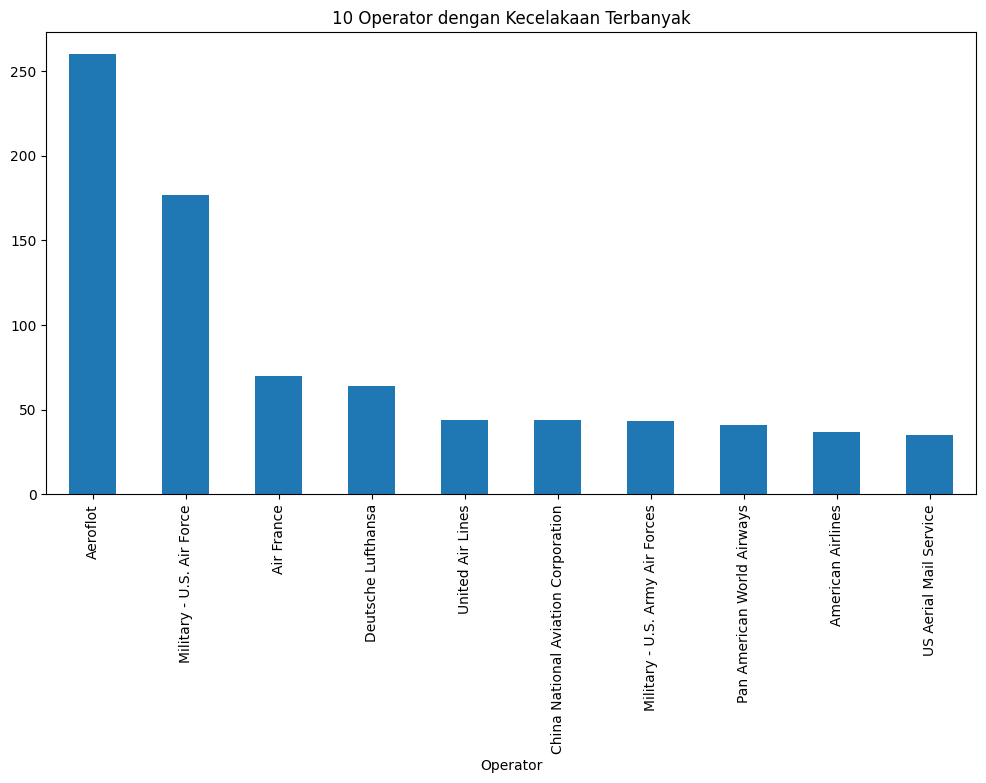

In [ ]:
plt.figure(figsize=(12,6))

df["Operator"].value_counts().head(10).plot(kind="bar")

plt.title("10 Operator dengan Kecelakaan Terbanyak")

plt.show()


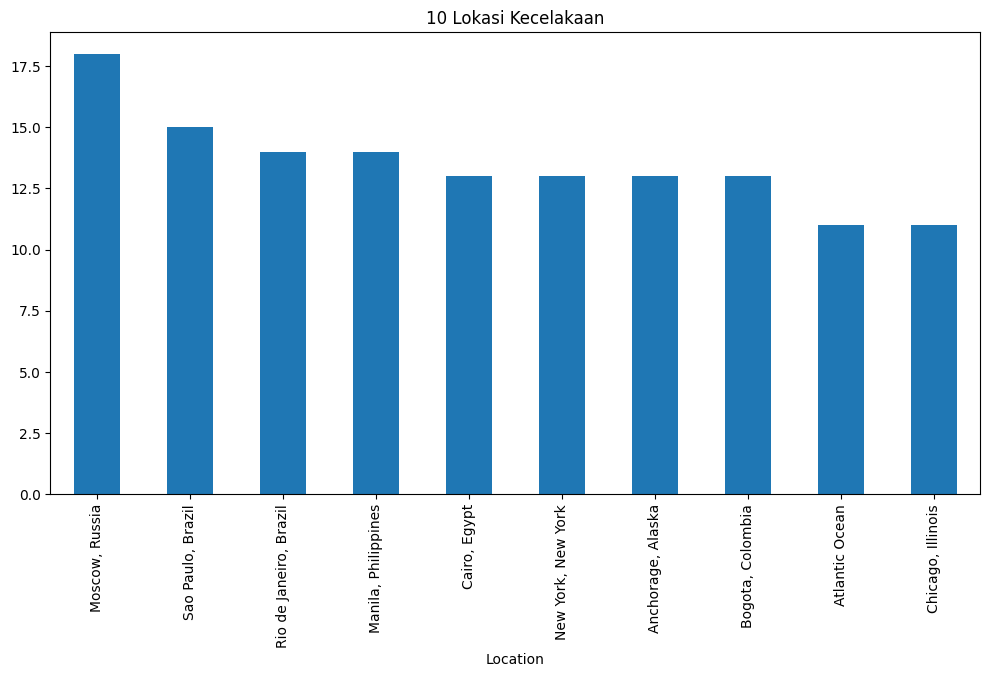

In [ ]:
plt.figure(figsize=(12,6))

df["Location"].value_counts().head(10).plot(kind="bar")

plt.title("10 Lokasi Kecelakaan")

plt.show()

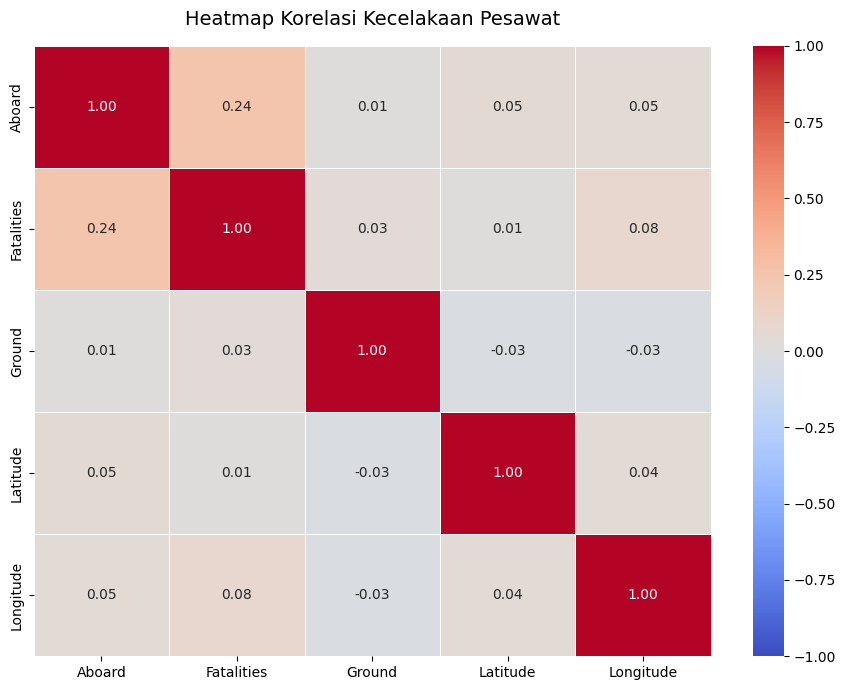

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Membaca file dataset
df = pd.read_csv('dataset-2.csv')

# 2. Menghapus kolom 'Unnamed' (kolom sampah hasil parsing CSV)
unnamed_cols = [col for col in df.columns if 'Unnamed' in col]
df_clean = df.drop(columns=unnamed_cols)

# 3. Mengubah kolom numerik yang terbaca sebagai teks/object menjadi angka (float/int)
numeric_cols = ['Aboard', 'Fatalities', 'Ground', 'Latitude', 'Longitude']
for col in numeric_cols:
  if col in df_clean.columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# 4. Mengambil hanya kolom numerik dan menghitung matriks korelasi
df_numeric = df_clean[numeric_cols]
corr_matrix = df_numeric.corr()

# 5. Membuat visualisasi Heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,  # Menampilkan nilai angka korelasi di dalam kotak
    fmt='.2f',  # Format 2 angka di belakang koma
    cmap='coolwarm',  # Skema warna (Biru = Negatif, Merah = Positif)
    vmin=-1,
    vmax=1,  # Batas skala korelasi (-1 sampai 1)
    linewidths=0.5,  # Garis pemisah antar kotak
    cbar=True,
)

plt.title('Heatmap Korelasi Kecelakaan Pesawat', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [ ]:
df['Fatalities'] = pd.to_numeric(df['Fatalities'], errors='coerce')
df['Aboard'] = pd.to_numeric(df['Aboard'], errors='coerce')

df["HighFatality"] = (
    df["Fatalities"] / df["Aboard"]
)

df["HighFatality"] = (
    df["HighFatality"] >= 0.8
).astype(int)

In [ ]:
df = df[df["Aboard"] > 0]

In [ ]:
encoder = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = encoder.fit_transform(df[col])

In [ ]:
X = df.drop(columns=["HighFatality"])
y = df["HighFatality"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("Accuracy")

accuracy_score(y_test, y_pred)

Accuracy


0.909330985915493

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.65      0.79       295
           1       0.89      1.00      0.94       841

    accuracy                           0.91      1136
   macro avg       0.95      0.83      0.87      1136
weighted avg       0.92      0.91      0.90      1136



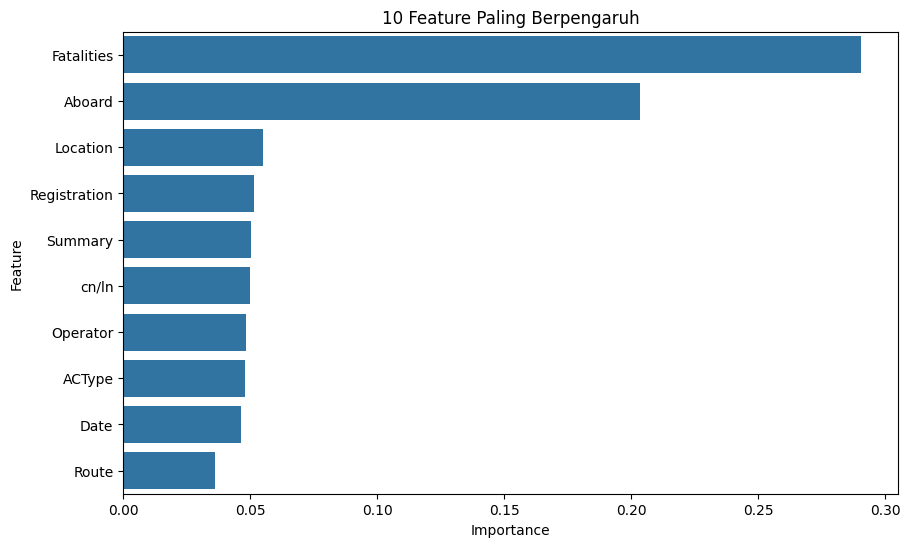

In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("10 Feature Paling Berpengaruh")

plt.show()

=== DATA INFO SETELAH CLEANING ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5825 entries, 0 to 5824
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          5756 non-null   datetime64[ns]
 1   Time          3680 non-null   object        
 2   Location      5767 non-null   object        
 3   Latitude      2106 non-null   float64       
 4   Longitude     2112 non-null   float64       
 5   Operator      5743 non-null   object        
 6   Flight#       1367 non-null   object        
 7   Route         4254 non-null   object        
 8   ACType        5727 non-null   object        
 9   Registration  5398 non-null   object        
 10  cn/ln         4541 non-null   object        
 11  Aboard        5693 non-null   float64       
 12  Fatalities    5720 non-null   float64       
 13  Ground        5682 non-null   float64       
 14  Summary       5492 non-null   object        
 15  Rea

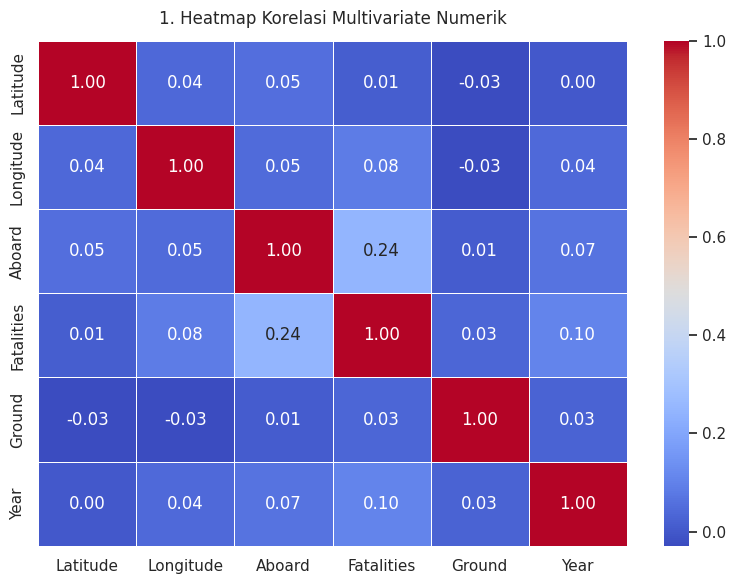

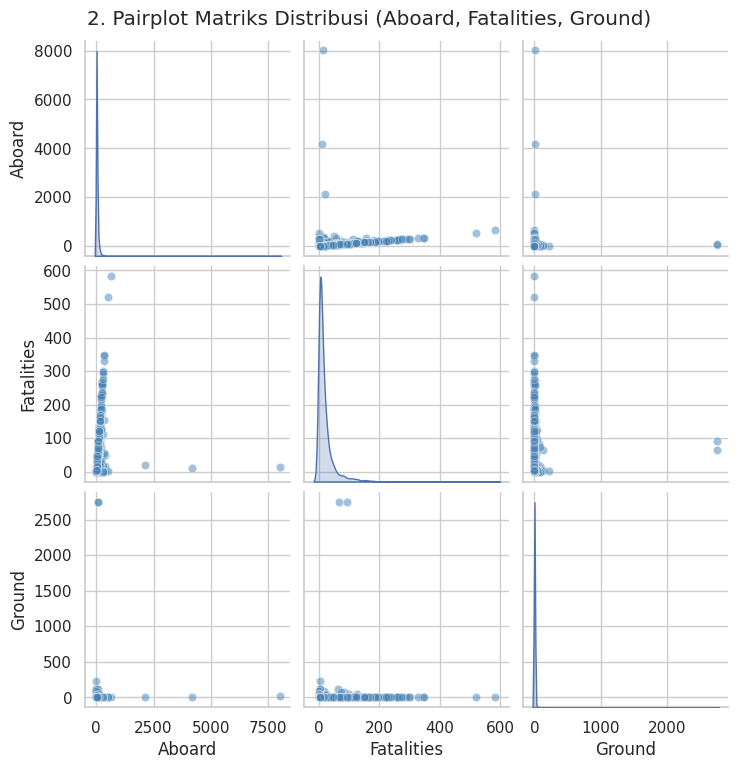

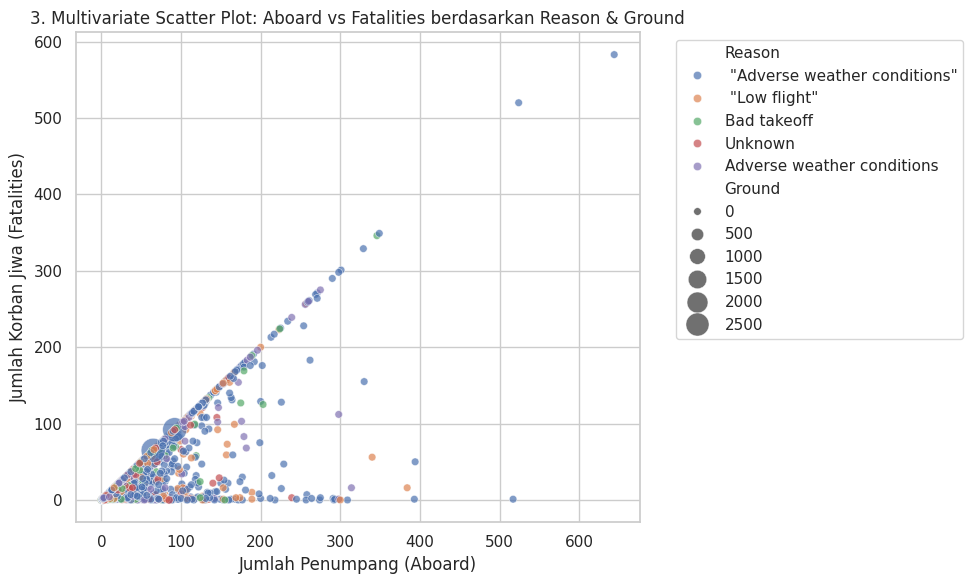


=== SUMMARY TABLE: Rata-Rata Korban Berdasarkan Penyebab Utamanya ===
                               Aboard  Fatalities  Ground
Reason                                                   
 "Adverse weather conditions"   32.39       22.55    2.75
 "Low flight"                   26.84       19.14    0.57
Adverse weather conditions      27.19       21.48    0.82
Bad takeoff                     23.20       18.37    0.92
Unknown                         17.07       14.15    0.34


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set tema visualisasi
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# 1. LOAD & CLEANING DATASET
# ---------------------------------------------------------
df = pd.read_csv('dataset-2.csv')

# Hapus kolom Unnamed (kolom sampah)
df = df.drop(columns=[col for col in df.columns if 'Unnamed' in col])

# Konversi kolom numerik
numeric_cols = ['Aboard', 'Fatalities', 'Ground', 'Latitude', 'Longitude']
for col in numeric_cols:
  if col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Extract Tahun dari kolom Date
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', dayfirst=True)
df['Year'] = df['Date'].dt.year

print('=== DATA INFO SETELAH CLEANING ===')
print(df.info())

# ---------------------------------------------------------
# 2. HEATMAP KORELASI MULTIVARIATE
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
)
plt.title('1. Heatmap Korelasi Multivariate Numerik', fontsize=12, pad=12)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. PAIRPLOT (Matriks Sebaran Antar Variabel Numerik)
# ---------------------------------------------------------
sns.pairplot(
    df[['Aboard', 'Fatalities', 'Ground']],
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 'color': 'steelblue'},
)
plt.suptitle(
    '2. Pairplot Matriks Distribusi (Aboard, Fatalities, Ground)', y=1.02
)
plt.show()

# ---------------------------------------------------------
# 4. MULTIVARIATE SCATTER PLOT (4 Variabel Sekaligus)
# X: Aboard, Y: Fatalities, Hue: Reason (Warna), Size: Ground (Ukuran)
# ---------------------------------------------------------
# Ambil 5 kategori penyebab terbanyak agar plot tidak berantakan
top_reasons = df['Reason'].value_counts().head(5).index
df_filtered = df[df['Reason'].isin(top_reasons)].dropna(
    subset=['Aboard', 'Fatalities']
)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_filtered,
    x='Aboard',
    y='Fatalities',
    hue='Reason',
    size='Ground',
    sizes=(30, 300),
    alpha=0.7,
)
plt.title(
    '3. Multivariate Scatter Plot: Aboard vs Fatalities berdasarkan Reason &'
    ' Ground',
    fontsize=12,
)
plt.xlabel('Jumlah Penumpang (Aboard)')
plt.ylabel('Jumlah Korban Jiwa (Fatalities)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5. AGREGASI & PIVOT TABLE MULTIVARIATE
# ---------------------------------------------------------
print('\n=== SUMMARY TABLE: Rata-Rata Korban Berdasarkan Penyebab Utamanya ===')
summary_table = (
    df_filtered.groupby('Reason')[['Aboard', 'Fatalities', 'Ground']]
    .mean()
    .round(2)
)
print(summary_table)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# =========================================================
# 1. LOAD DATASET
# =========================================================
df = pd.read_csv('dataset-2.csv')

# =========================================================
# 2. DATA CLEANING & FEATURE ENGINEERING
# =========================================================
# A. Hapus kolom 'Unnamed' (kolom sampah)
unnamed_cols = [c for c in df.columns if 'Unnamed' in c]
df = df.drop(columns=unnamed_cols)

# B. Hapus kolom ID/teks acak yang tidak relevan untuk prediksi Machine Learning
drop_cols = [
    'Flight#',
    'Registration',
    'cn/ln',
    'Summary',
    'Time',
    'Latitude',
    'Longitude',
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# C. Konversi kolom numerik
num_cols = ['Aboard', 'Fatalities', 'Ground']
for col in num_cols:
  df[col] = pd.to_numeric(df[col], errors='coerce')

# D. Hapus baris yang tidak memiliki target/fitur utama (Aboard atau Fatalities kosong)
df = df.dropna(subset=['Aboard', 'Fatalities'])

# E. MEMBUAT TARGET VARIABEL:
# 1) Target Regresi: Fatality Rate (Rasio 0.0 sampai 1.0)
df['Fatality_Rate'] = (df['Fatalities'] / df['Aboard']).clip(0.0, 1.0)
# 2) Target Klasifikasi: Is_High_Fatality (1 jika >= 50% meninggal, 0 jika < 50%)
df['Is_High_Fatality'] = (df['Fatality_Rate'] >= 0.5).astype(int)

# F. EKSTRAKSI FITUR WAKTU (Temporal Features)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', dayfirst=True)
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek


# G. PENYERAGAMAN KATEGORI (Group Rare Categories)
def simplify_category(series, top_n=10):
  series = series.fillna('Unknown').astype(str).str.strip()
  top_cats = series.value_counts().head(top_n).index
  return series.apply(lambda x: x if x in top_cats else 'Other')


df['Operator_Grouped'] = simplify_category(df['Operator'], top_n=10)
df['Reason_Grouped'] = simplify_category(df['Reason'], top_n=8)
df['ACType_Grouped'] = simplify_category(df['ACType'], top_n=10)

# =========================================================
# 3. PEMISAHAN FITUR (X) DAN TARGET (y)
# =========================================================
feature_columns = [
    'Aboard',
    'Ground',
    'Year',
    'Month',
    'DayOfWeek',
    'Operator_Grouped',
    'Reason_Grouped',
    'ACType_Grouped',
]

X = df[feature_columns]
y_regression = df['Fatality_Rate']  # Gunakan ini jika membuat model Regresi
y_classification = df[
    'Is_High_Fatality'
]  # Gunakan ini jika membuat model Klasifikasi

# =========================================================
# 4. TRAIN-TEST SPLIT (80% Train, 20% Test)
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_regression,  # Ubah ke y_classification jika memprediksi Kelas High/Low
    test_size=0.2,
    random_state=42,
)

# =========================================================
# 5. TRANSFORMASI PIPELINE (Imputation + Scaling + One-Hot)
# =========================================================
num_features = ['Aboard', 'Ground', 'Year', 'Month', 'DayOfWeek']
cat_features = ['Operator_Grouped', 'Reason_Grouped', 'ACType_Grouped']

# Pipeline untuk Angka
num_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]
)

# Pipeline untuk Teks/Kategori
cat_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
        (
            'encoder',
            OneHotEncoder(handle_unknown='ignore', sparse_output=False),
        ),
    ]
)

# Gabungkan Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features),
    ]
)

# Eksekusi Transformasi ke Data Train & Test
X_train_ready = preprocessor.fit_transform(X_train)
X_test_ready = preprocessor.transform(X_test)

print('✅ PREPROCESSING SELESAI!')
print(f'Ukuran Data Latih (X_train) : {X_train_ready.shape}')
print(f'Ukuran Data Uji   (X_test)  : {X_test_ready.shape}')

✅ PREPROCESSING SELESAI!
Ukuran Data Latih (X_train) : (4548, 36)
Ukuran Data Uji   (X_test)  : (1137, 36)


## Kesimpulan

1. Dataset berhasil dibersihkan melalui proses preprocessing.
2. Exploratory Data Analysis menunjukkan distribusi kecelakaan berdasarkan operator, lokasi, jumlah penumpang, dan korban.
3. Model Random Forest berhasil digunakan untuk memprediksi tingkat fatalitas kecelakaan pesawat.
4. Performa model dievaluasi menggunakan Accuracy, Precision, Recall, F1-Score, dan Confusion Matrix.
5. Feature Importance menunjukkan variabel yang paling berpengaruh terhadap prediksi.